# PE7023 - Project
## Pipesim flow model comparison


Diego de Miranda Gomes

Emuobosa Patience Ojoboh

In [1]:
# %pip install pandas

✅ Figures will save to : C:\Users\Emuobosa P Ojoboh\OneDrive - University of Oklahoma\Documents\TU Semesters\Spring 2026 Classes\PE-7023-01_Adv_Production_Design\Project\PE7023-Project\report\figs
✅ Data directory       : C:\Users\Emuobosa P Ojoboh\OneDrive - University of Oklahoma\Documents\TU Semesters\Spring 2026 Classes\PE-7023-01_Adv_Production_Design\Project\PE7023-Project\python\datasets
✅ figs folder exists   : True
✅ Data loaded.


,Well,TVD (ft),Pwf (psia),Python Pwh (psia),M1 Pwh TUFFP,M2 Pwh Gomez/Xiao,ΔP Python (psi),ΔP M1 (psi),ΔP M2 (psi),M1 Rate (STB/d),M2 Rate (STB/d),Rate Δ M1−M2
0,W1,5981,2737.5,820.0,1291.725,1304.337,1917.5,1445.8,1433.2,6030.355,6047.282,-16.9
1,W2,6051,2759.7,820.0,1289.408,1317.340,1939.7,1470.3,1442.4,7226.990,7228.927,-1.9
2,W3,5989,2735.7,820.0,1286.608,1308.319,1915.7,1449.1,1427.4,6048.063,6032.632,15.4
3,W4,5862,2710.9,820.0,1282.128,1316.516,1890.9,1428.8,1394.4,7250.345,7231.751,18.6
4,W5,5702,2670.9,820.0,1309.736,1330.344,1850.9,1361.2,1340.6,5967.586,5950.865,16.7
5,W6,5742,2681.8,820.0,1310.464,1346.231,1861.8,1371.3,1335.6,5965.037,5946.330,18.7
6,W7,5731,2676.4,820.0,1318.526,1336.170,1856.4,1357.9,1340.2,6535.742,6545.477,-9.7



Total  M1 :    45024.1 STB/d
Total  M2 :    44983.3 STB/d
Avg Pwh diff (M2−M1): +24.4 psia
✅ Traverse functions defined.


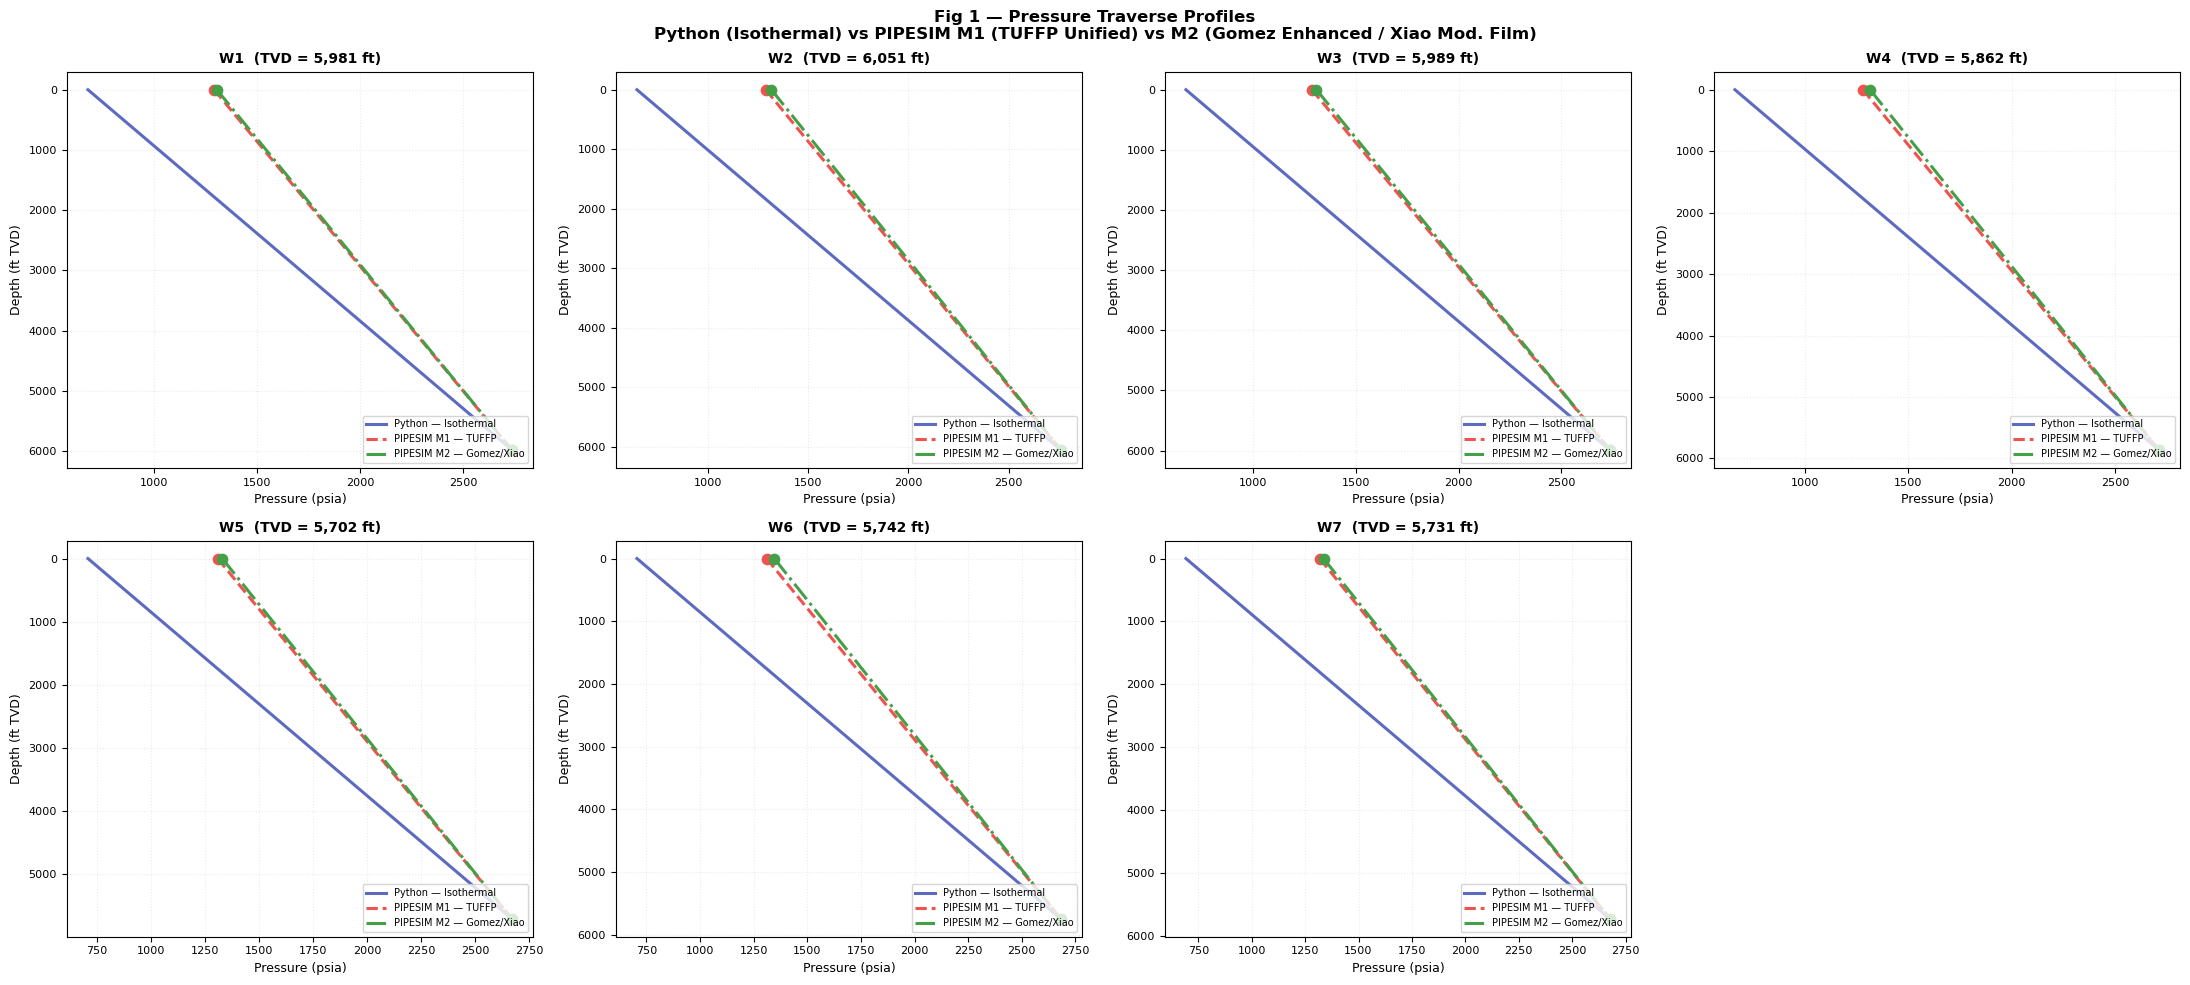

✅ Saved → C:\Users\Emuobosa P Ojoboh\OneDrive - University of Oklahoma\Documents\TU Semesters\Spring 2026 Classes\PE-7023-01_Adv_Production_Design\Project\PE7023-Project\report\figs\pipesim_01_pressure_traverse.png


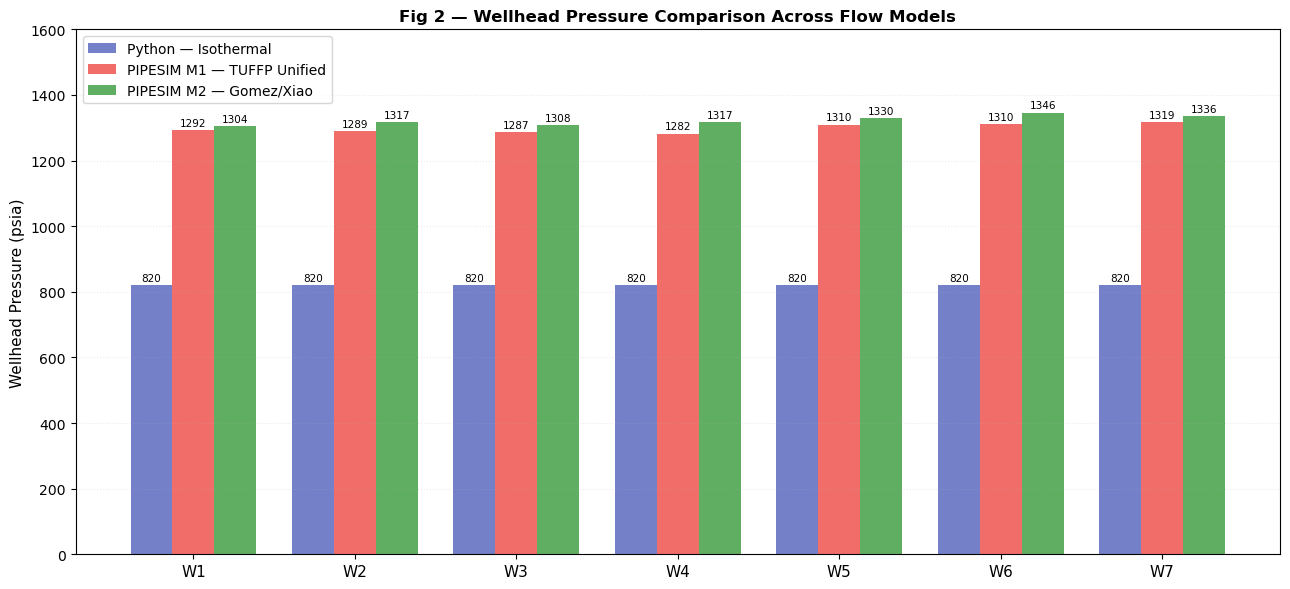

✅ Saved → C:\Users\Emuobosa P Ojoboh\OneDrive - University of Oklahoma\Documents\TU Semesters\Spring 2026 Classes\PE-7023-01_Adv_Production_Design\Project\PE7023-Project\report\figs\pipesim_02_wellhead_pressure.png


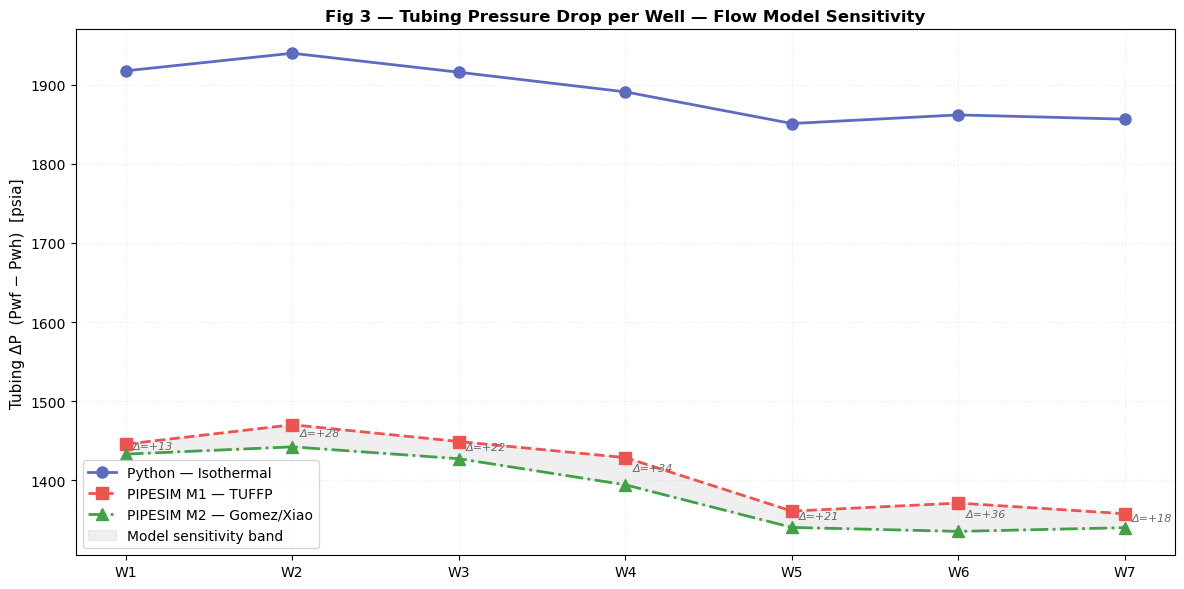

✅ Saved → C:\Users\Emuobosa P Ojoboh\OneDrive - University of Oklahoma\Documents\TU Semesters\Spring 2026 Classes\PE-7023-01_Adv_Production_Design\Project\PE7023-Project\report\figs\pipesim_03_tubing_dp.png


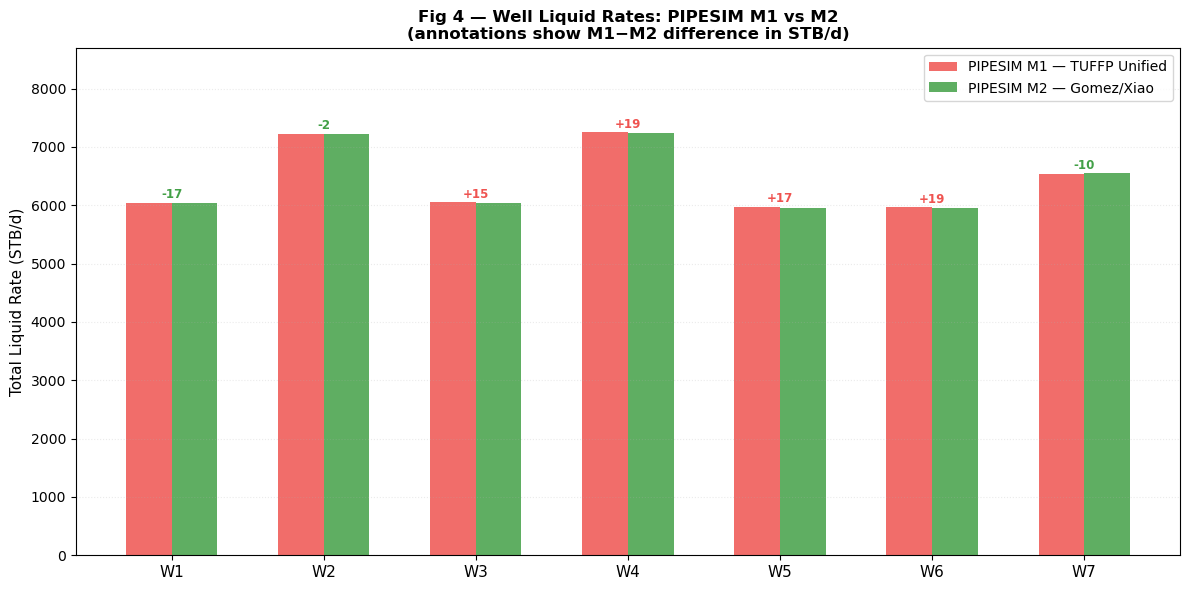

✅ Saved → C:\Users\Emuobosa P Ojoboh\OneDrive - University of Oklahoma\Documents\TU Semesters\Spring 2026 Classes\PE-7023-01_Adv_Production_Design\Project\PE7023-Project\report\figs\pipesim_04_liquid_rates.png


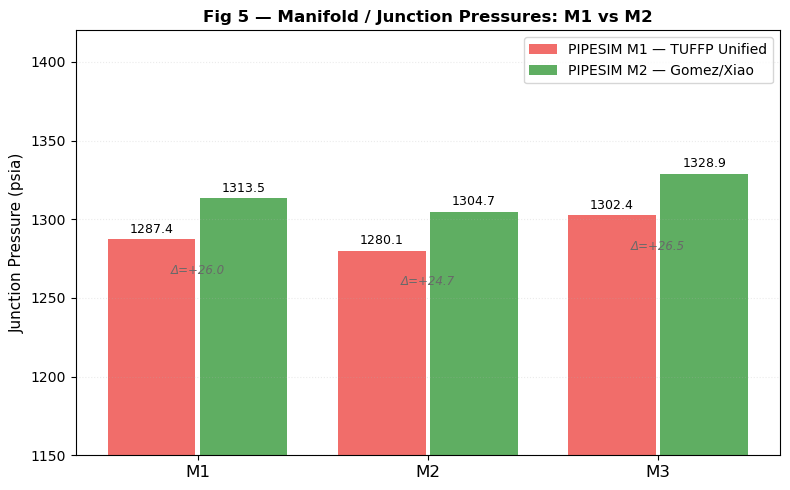

✅ Saved → C:\Users\Emuobosa P Ojoboh\OneDrive - University of Oklahoma\Documents\TU Semesters\Spring 2026 Classes\PE-7023-01_Adv_Production_Design\Project\PE7023-Project\report\figs\pipesim_05_junction_pressures.png


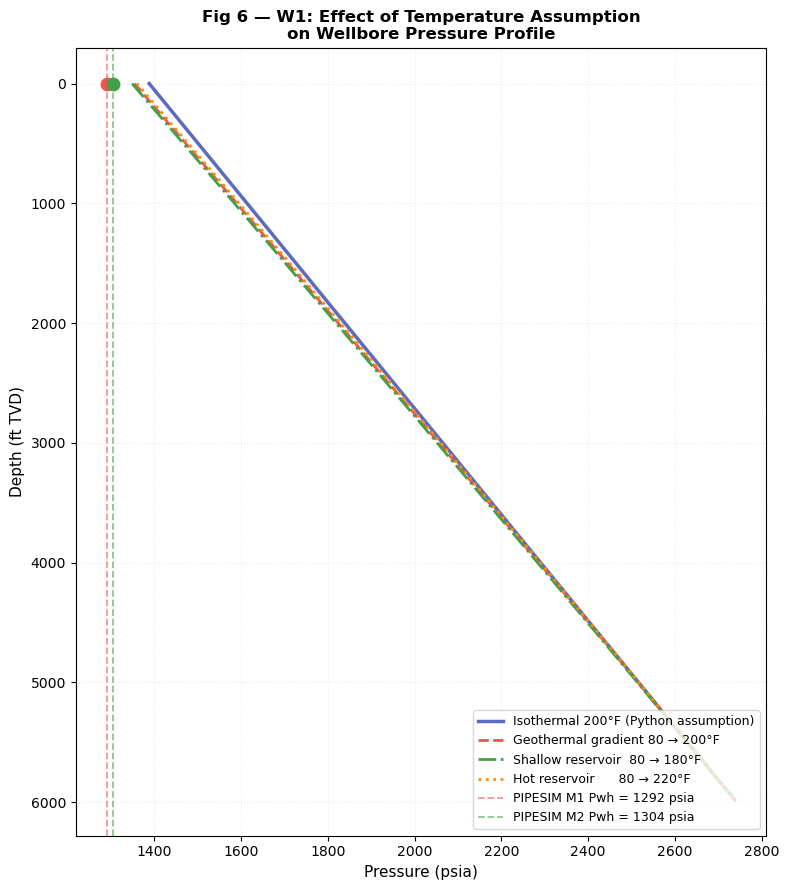

✅ Saved → C:\Users\Emuobosa P Ojoboh\OneDrive - University of Oklahoma\Documents\TU Semesters\Spring 2026 Classes\PE-7023-01_Adv_Production_Design\Project\PE7023-Project\report\figs\pipesim_06_temperature_effect.png

ALL FIGURES SAVED TO:
  pipesim_01_pressure_traverse.png
  pipesim_02_wellhead_pressure.png
  pipesim_03_tubing_dp.png
  pipesim_04_liquid_rates.png
  pipesim_05_junction_pressures.png
  pipesim_06_temperature_effect.png

Network totals:
  M1 (TUFFP)      :   45,024.1 STB/d
  M2 (Gomez/Xiao) :   44,983.3 STB/d
  Difference      :      +40.9 STB/d

Avg wellhead pressure:
  M1 :   1298.4 psia
  M2 :   1322.8 psia
  Δ  :    +24.4 psia

Avg tubing pressure drop:
  Python :   1890.4 psia
  M1     :   1412.0 psia
  M2     :   1387.7 psia


In [3]:
# ── CELL 1: Imports & Paths ──────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ── Hardcoded paths for your machine ─────────────────────────
BASE     = Path(r"C:\Users\Emuobosa P Ojoboh\OneDrive - University of Oklahoma\Documents\TU Semesters\Spring 2026 Classes\PE-7023-01_Adv_Production_Design\Project\PE7023-Project\python")
FIGS_DIR = BASE.parent / "report" / "figs"
DATA_DIR = BASE / "datasets"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ Figures will save to : {FIGS_DIR}")
print(f"✅ Data directory       : {DATA_DIR}")
print(f"✅ figs folder exists   : {FIGS_DIR.exists()}")


# ── CELL 2: Data ─────────────────────────────────────────────
WELLS_LIST = ["W1", "W2", "W3", "W4", "W5", "W6", "W7"]

WELLS = {
    "W1": {"TVD_ft": 5981, "pwf_psia": 2737.5},
    "W2": {"TVD_ft": 6051, "pwf_psia": 2759.7},
    "W3": {"TVD_ft": 5989, "pwf_psia": 2735.7},
    "W4": {"TVD_ft": 5862, "pwf_psia": 2710.9},
    "W5": {"TVD_ft": 5702, "pwf_psia": 2670.9},
    "W6": {"TVD_ft": 5742, "pwf_psia": 2681.8},
    "W7": {"TVD_ft": 5731, "pwf_psia": 2676.4},
}

PYTHON_PWH = {w: 820.0 for w in WELLS_LIST}

# PIPESIM Model 1 — TUFFP Unified (TUFFP v. 2011.1 2-Phase)
M1_PWH = {
    "W1": 1291.725, "W2": 1289.408, "W3": 1286.608,
    "W4": 1282.128, "W5": 1309.736, "W6": 1310.464, "W7": 1318.526,
}

# PIPESIM Model 2 — Gomez Enhanced (Vertical) + Xiao Mod. Film (Horizontal)
M2_PWH = {
    "W1": 1304.337, "W2": 1317.340, "W3": 1308.319,
    "W4": 1316.516, "W5": 1330.344, "W6": 1346.231, "W7": 1336.170,
}

M1_RATES = {
    "W1": 6030.355, "W2": 7226.990, "W3": 6048.063,
    "W4": 7250.345, "W5": 5967.586, "W6": 5965.037, "W7": 6535.742,
}
M2_RATES = {
    "W1": 6047.282, "W2": 7228.927, "W3": 6032.632,
    "W4": 7231.751, "W5": 5950.865, "W6": 5946.330, "W7": 6545.477,
}

M1_JUNC = {"M1": 1287.444, "M2": 1280.061, "M3": 1302.377}
M2_JUNC = {"M1": 1313.488, "M2": 1304.743, "M3": 1328.924}

C = {"python": "#5C6BC0", "m1": "#EF5350", "m2": "#43A047"}

print("✅ Data loaded.")


# ── CELL 3: Summary Table ─────────────────────────────────────
rows = []
for w in WELLS_LIST:
    pwf = WELLS[w]["pwf_psia"]
    rows.append({
        "Well"              : w,
        "TVD (ft)"          : WELLS[w]["TVD_ft"],
        "Pwf (psia)"        : pwf,
        "Python Pwh (psia)" : PYTHON_PWH[w],
        "M1 Pwh TUFFP"      : M1_PWH[w],
        "M2 Pwh Gomez/Xiao" : M2_PWH[w],
        "ΔP Python (psi)"   : round(pwf - PYTHON_PWH[w], 1),
        "ΔP M1 (psi)"       : round(pwf - M1_PWH[w], 1),
        "ΔP M2 (psi)"       : round(pwf - M2_PWH[w], 1),
        "M1 Rate (STB/d)"   : M1_RATES[w],
        "M2 Rate (STB/d)"   : M2_RATES[w],
        "Rate Δ M1−M2"      : round(M1_RATES[w] - M2_RATES[w], 1),
    })

df = pd.DataFrame(rows)
display(df)
print(f"\nTotal  M1 : {sum(M1_RATES.values()):>10.1f} STB/d")
print(f"Total  M2 : {sum(M2_RATES.values()):>10.1f} STB/d")
print(f"Avg Pwh diff (M2−M1): {np.mean([M2_PWH[w]-M1_PWH[w] for w in WELLS_LIST]):+.1f} psia")


# ── CELL 4: Pressure Traverse Functions ──────────────────────
def pressure_traverse_isothermal(pwf_psia, TVD_ft, q_STBd=6000,
                                  pipe_id_in=3.5, n=60):
    """Isothermal traverse — same assumption as Python model."""
    dz      = TVD_ft / (n - 1)
    A       = np.pi * (pipe_id_in / 24) ** 2
    vel     = q_STBd * 5.615 / (86400 * A)
    rho_mix = 48.0
    dPgrav  = rho_mix / 144.0
    dPfric  = 0.018 * rho_mix * vel**2 / (2 * 32.174 * (pipe_id_in/12) * 144)
    dP_ft   = dPgrav + dPfric
    depths  = np.linspace(TVD_ft, 0, n)
    P       = np.zeros(n)
    P[0]    = pwf_psia
    for i in range(1, n):
        P[i] = P[i-1] - dP_ft * dz
    return depths[::-1], P[::-1]


def pressure_traverse_geothermal(pwf_psia, TVD_ft, q_STBd=6000,
                                  T_surf_F=80, T_BH_F=200,
                                  pipe_id_in=3.5, n=60):
    """Traverse with temperature-dependent fluid density."""
    dz     = TVD_ft / (n - 1)
    depths = np.linspace(TVD_ft, 0, n)
    P      = np.zeros(n)
    P[0]   = pwf_psia
    for i in range(1, n):
        depth_i = depths[i]
        T_F     = T_surf_F + (T_BH_F - T_surf_F) * (depth_i / TVD_ft)
        rho_oil   = 52.0 * (1 - 0.0004 * (T_F - 60))
        rho_water = 62.4 * (1 - 0.0002 * (T_F - 60))
        rho_gas   = np.clip(
            0.9 * (P[i-1]/14.7) / (T_F+459.67) * (520/14.7) * 0.0764, 0.5, 5.0)
        rho_mix = 0.65*(0.95*rho_oil + 0.05*rho_water) + 0.35*rho_gas
        P[i] = P[i-1] - (rho_mix / 144.0) * dz
    return depths[::-1], P[::-1]

print("✅ Traverse functions defined.")


# ── CELL 5: Plot 1 — Pressure Traverse per Well ──────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle(
    "Fig 1 — Pressure Traverse Profiles\n"
    "Python (Isothermal) vs PIPESIM M1 (TUFFP Unified) vs M2 (Gomez Enhanced / Xiao Mod. Film)",
    fontsize=12, fontweight="bold"
)
axes = axes.flatten()

for idx, wname in enumerate(WELLS_LIST):
    ax  = axes[idx]
    TVD = WELLS[wname]["TVD_ft"]
    pwf = WELLS[wname]["pwf_psia"]

    d, p = pressure_traverse_isothermal(pwf, TVD, q_STBd=M1_RATES[wname])
    ax.plot(p, d, color=C["python"], lw=2.2, label="Python — Isothermal")

    for label, pwh_dict, col, ls in [
        ("PIPESIM M1 — TUFFP",      M1_PWH, C["m1"], "--"),
        ("PIPESIM M2 — Gomez/Xiao", M2_PWH, C["m2"], "-."),
    ]:
        pwh = pwh_dict[wname]
        ax.plot([pwh, pwf], [0, TVD], color=col, lw=2.2, ls=ls, label=label)
        ax.scatter([pwh], [0],   color=col, s=55, zorder=5)
        ax.scatter([pwf], [TVD], color=col, s=55, zorder=5)

    ax.invert_yaxis()
    ax.set_title(f"{wname}  (TVD = {TVD:,} ft)", fontsize=10, fontweight="bold")
    ax.set_xlabel("Pressure (psia)", fontsize=9)
    ax.set_ylabel("Depth (ft TVD)",  fontsize=9)
    ax.grid(True, alpha=0.25, linestyle=":")
    ax.legend(fontsize=7, loc="lower right")
    ax.tick_params(labelsize=8)

axes[-1].set_visible(False)
plt.tight_layout()
save_path = FIGS_DIR / "pipesim_01_pressure_traverse.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {save_path}")


# ── CELL 6: Plot 2 — Wellhead Pressure Bar Chart ─────────────
x  = np.arange(len(WELLS_LIST))
bw = 0.26

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - bw, [PYTHON_PWH[w] for w in WELLS_LIST], bw,
            label="Python — Isothermal",        color=C["python"], alpha=0.85)
b2 = ax.bar(x,      [M1_PWH[w]     for w in WELLS_LIST], bw,
            label="PIPESIM M1 — TUFFP Unified", color=C["m1"],    alpha=0.85)
b3 = ax.bar(x + bw, [M2_PWH[w]     for w in WELLS_LIST], bw,
            label="PIPESIM M2 — Gomez/Xiao",    color=C["m2"],    alpha=0.85)

for bars in [b1, b2, b3]:
    for rect in bars:
        h = rect.get_height()
        ax.annotate(f"{h:.0f}",
                    xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(WELLS_LIST, fontsize=11)
ax.set_ylabel("Wellhead Pressure (psia)", fontsize=11)
ax.set_title("Fig 2 — Wellhead Pressure Comparison Across Flow Models",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.25, linestyle=":")
ax.set_ylim(0, 1600)
plt.tight_layout()
save_path = FIGS_DIR / "pipesim_02_wellhead_pressure.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {save_path}")


# ── CELL 7: Plot 3 — Tubing Pressure Drop ────────────────────
dp_py = [WELLS[w]["pwf_psia"] - PYTHON_PWH[w] for w in WELLS_LIST]
dp_m1 = [WELLS[w]["pwf_psia"] - M1_PWH[w]     for w in WELLS_LIST]
dp_m2 = [WELLS[w]["pwf_psia"] - M2_PWH[w]     for w in WELLS_LIST]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(WELLS_LIST, dp_py, "o-",  color=C["python"], lw=2, ms=8, label="Python — Isothermal")
ax.plot(WELLS_LIST, dp_m1, "s--", color=C["m1"],    lw=2, ms=8, label="PIPESIM M1 — TUFFP")
ax.plot(WELLS_LIST, dp_m2, "^-.", color=C["m2"],    lw=2, ms=8, label="PIPESIM M2 — Gomez/Xiao")
ax.fill_between(WELLS_LIST, dp_m1, dp_m2,
                alpha=0.12, color="gray", label="Model sensitivity band")

for i, (v1, v2) in enumerate(zip(dp_m1, dp_m2)):
    ax.annotate(f"Δ={v1-v2:+.0f}",
                xy=(i, (v1+v2)/2), xytext=(5, 0),
                textcoords="offset points",
                fontsize=8, color="dimgray", style="italic")

ax.set_ylabel("Tubing ΔP  (Pwf − Pwh)  [psia]", fontsize=11)
ax.set_title("Fig 3 — Tubing Pressure Drop per Well — Flow Model Sensitivity",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25, linestyle=":")
plt.tight_layout()
save_path = FIGS_DIR / "pipesim_03_tubing_dp.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {save_path}")


# ── CELL 8: Plot 4 — Liquid Rate Comparison ──────────────────
x  = np.arange(len(WELLS_LIST))
bw = 0.30

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - bw/2, [M1_RATES[w] for w in WELLS_LIST], bw,
            label="PIPESIM M1 — TUFFP Unified", color=C["m1"], alpha=0.85)
b2 = ax.bar(x + bw/2, [M2_RATES[w] for w in WELLS_LIST], bw,
            label="PIPESIM M2 — Gomez/Xiao",    color=C["m2"], alpha=0.85)

for i, ww in enumerate(WELLS_LIST):
    diff = M1_RATES[ww] - M2_RATES[ww]
    col  = C["m1"] if diff > 0 else C["m2"]
    ax.text(i, max(M1_RATES[ww], M2_RATES[ww]) + 80,
            f"{diff:+.0f}", ha="center", fontsize=8.5,
            color=col, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(WELLS_LIST, fontsize=11)
ax.set_ylabel("Total Liquid Rate (STB/d)", fontsize=11)
ax.set_title("Fig 4 — Well Liquid Rates: PIPESIM M1 vs M2\n"
             "(annotations show M1−M2 difference in STB/d)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.25, linestyle=":")
ax.set_ylim(0, max(M1_RATES.values()) * 1.2)
plt.tight_layout()
save_path = FIGS_DIR / "pipesim_04_liquid_rates.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {save_path}")


# ── CELL 9: Plot 5 — Junction Pressures ──────────────────────
junctions = ["M1", "M2", "M3"]
m1_j = [M1_JUNC[j] for j in junctions]
m2_j = [M2_JUNC[j] for j in junctions]

xj = np.arange(len(junctions))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(xj - 0.2, m1_j, 0.38, label="PIPESIM M1 — TUFFP Unified", color=C["m1"], alpha=0.85)
ax.bar(xj + 0.2, m2_j, 0.38, label="PIPESIM M2 — Gomez/Xiao",    color=C["m2"], alpha=0.85)

for i, (v1, v2) in enumerate(zip(m1_j, m2_j)):
    ax.text(i - 0.2, v1 + 4,  f"{v1:.1f}", ha="center", fontsize=9)
    ax.text(i + 0.2, v2 + 4,  f"{v2:.1f}", ha="center", fontsize=9)
    ax.text(i, min(v1,v2) - 22, f"Δ={v2-v1:+.1f}",
            ha="center", fontsize=8.5, color="dimgray", style="italic")

ax.set_xticks(xj)
ax.set_xticklabels(junctions, fontsize=12)
ax.set_ylabel("Junction Pressure (psia)", fontsize=11)
ax.set_title("Fig 5 — Manifold / Junction Pressures: M1 vs M2",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.25, linestyle=":")
ax.set_ylim(1150, 1420)
plt.tight_layout()
save_path = FIGS_DIR / "pipesim_05_junction_pressures.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {save_path}")


# ── CELL 10: Plot 6 — Temperature Assumption Effect ──────────
rep_well = "W1"
pwf = WELLS[rep_well]["pwf_psia"]
TVD = WELLS[rep_well]["TVD_ft"]

T_cases = [
    (200, 200, "Isothermal 200°F (Python assumption)", C["python"], "-",  2.5),
    ( 80, 200, "Geothermal gradient 80 → 200°F",       C["m1"],    "--", 2.0),
    ( 80, 180, "Shallow reservoir  80 → 180°F",         C["m2"],    "-.", 2.0),
    ( 80, 220, "Hot reservoir      80 → 220°F",         "#FF8F00",  ":",  2.0),
]

fig, ax = plt.subplots(figsize=(8, 9))
for T_s, T_b, label, col, ls, lw in T_cases:
    d, p = pressure_traverse_geothermal(
        pwf, TVD, q_STBd=M1_RATES[rep_well], T_surf_F=T_s, T_BH_F=T_b
    )
    ax.plot(p, d, lw=lw, color=col, ls=ls, label=label)

for model_lbl, pwh_val, col in [
    (f"PIPESIM M1 Pwh = {M1_PWH[rep_well]:.0f} psia", M1_PWH[rep_well], C["m1"]),
    (f"PIPESIM M2 Pwh = {M2_PWH[rep_well]:.0f} psia", M2_PWH[rep_well], C["m2"]),
]:
    ax.axvline(pwh_val, color=col, lw=1.3, ls="--", alpha=0.6, label=model_lbl)
    ax.scatter([pwh_val], [0], color=col, s=80, zorder=5)

ax.invert_yaxis()
ax.set_xlabel("Pressure (psia)", fontsize=11)
ax.set_ylabel("Depth (ft TVD)",  fontsize=11)
ax.set_title(
    f"Fig 6 — {rep_well}: Effect of Temperature Assumption\non Wellbore Pressure Profile",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.25, linestyle=":")
plt.tight_layout()
save_path = FIGS_DIR / "pipesim_06_temperature_effect.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {save_path}")


# ── CELL 11: Final Summary ────────────────────────────────────
print("\n" + "="*60)
print("ALL FIGURES SAVED TO:")
for f in sorted(FIGS_DIR.glob("pipesim_*.png")):
    print(f"  {f.name}")
print("="*60)
print(f"\nNetwork totals:")
print(f"  M1 (TUFFP)      : {sum(M1_RATES.values()):>10,.1f} STB/d")
print(f"  M2 (Gomez/Xiao) : {sum(M2_RATES.values()):>10,.1f} STB/d")
print(f"  Difference      : {sum(M1_RATES.values())-sum(M2_RATES.values()):>+10.1f} STB/d")
avg_m1 = np.mean(list(M1_PWH.values()))
avg_m2 = np.mean(list(M2_PWH.values()))
print(f"\nAvg wellhead pressure:")
print(f"  M1 : {avg_m1:>8.1f} psia")
print(f"  M2 : {avg_m2:>8.1f} psia")
print(f"  Δ  : {avg_m2-avg_m1:>+8.1f} psia")
avg_dp_py = np.mean([WELLS[w]["pwf_psia"]-PYTHON_PWH[w] for w in WELLS_LIST])
avg_dp_m1 = np.mean([WELLS[w]["pwf_psia"]-M1_PWH[w]     for w in WELLS_LIST])
avg_dp_m2 = np.mean([WELLS[w]["pwf_psia"]-M2_PWH[w]     for w in WELLS_LIST])
print(f"\nAvg tubing pressure drop:")
print(f"  Python : {avg_dp_py:>8.1f} psia")
print(f"  M1     : {avg_dp_m1:>8.1f} psia")
print(f"  M2     : {avg_dp_m2:>8.1f} psia")